# BioBert Drug Review Sentiment Classification

This notebook fine-tunes BioBERT for drug review sentiment classification. It is used as a transformer-based comparison against the TF-IDF + LinearSVC baseline. The goal is to evaluate whether a domain-specific biomedical language model can improves sentiment prediction for patient drug reviews

## Environment Setup

The following installation cell is only required when running the notebook in a fresh environment. It can be skipped if the dependencies are installed. 


In [1]:
!pip install kagglehub
!pip install transformers datasets accelerate scikit-learn pandas numpy torch sentencepiece tiktoken unidecode

## Imports

In [2]:
import kagglehub
import os
import pandas as pd
import re 
import html 
import torch 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from unidecode import unidecode
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import classification_report, confusion_matrix


/Users/stanleywijaya/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Loading

In [3]:
dataset_path = kagglehub.dataset_download('jessicali9530/kuc-hackathon-winter-2018')
drugs_train  = pd.read_csv(os.path.join(dataset_path, 'drugsComTrain_raw.csv'), encoding = 'utf-8')
drugs_test   = pd.read_csv(os.path.join(dataset_path, 'drugsComTest_raw.csv'),  encoding = 'utf-8')

The UCI/Kaggle drug review dataset is loaded using the same train/test split as the LinearSVC baseline. The main input feature is the review text, and the sentiment label is derived from the numeric rating. 

## Rating to Sentiment Mapping

In [4]:
# Create sentiment labels from ratings
SENTIMENT_LABEL_MAP = {
    0:"NEGATIVE",
    1:"NEUTRAL",
    2: "POSITIVE"
}

def rating_to_label(rating):
    rating = int(rating)

    if 1 <= rating <= 4:
        return 0   # negative
    elif 5 <= rating <= 6:
        return 1   # neutral
    else:
        return 2   # positive

drugs_train["sentiment"] = drugs_train["rating"].map(rating_to_label)
drugs_test["sentiment"] = drugs_test["rating"].map(rating_to_label)

In [5]:
drugs_train[["review", "rating", "sentiment"]].head()


,review,rating,sentiment
0,"""It has no side effect, I take it in combinati...",9,2
1,"""My son is halfway through his fourth week of ...",8,2
2,"""I used to take another oral contraceptive, wh...",5,1
3,"""This is my first time using any form of birth...",8,2
4,"""Suboxone has completely turned my life around...",9,2


The same rating to sentiment mapping is used as the LinearSVC baseline to make the comparison fair: ratings 1-4 are Negative, 5-6 are Neutral and 7-10 are positive. 

## Text Preprocessing

In [6]:
def normalize_text(text):
    text = html.unescape(text)
    text = unidecode(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [7]:
drugs_train["clean_review"] = drugs_train["review"].apply(normalize_text)
drugs_test["clean_review"] = drugs_test["review"].apply(normalize_text)

A light text normalization is applied before BioBERT tokenization. The original 'review' column is preserved for inspection, while normalized text is stored in 'clean_review'.

## Dataset Sampling

In [8]:
train_class_size = 1700 

train_data = (drugs_train.groupby("sentiment",group_keys = False).sample(n=train_class_size, random_state = 42))
test_data = (drugs_test.groupby("sentiment",group_keys=False).sample(frac = 5000 / len(drugs_test), random_state=42))

print(train_data["sentiment"].map(SENTIMENT_LABEL_MAP).value_counts())
print(test_data["sentiment"].map(SENTIMENT_LABEL_MAP).value_counts())

sentiment
NEGATIVE    1700
NEUTRAL     1700
POSITIVE    1700
Name: count, dtype: int64
sentiment
POSITIVE    3296
NEGATIVE    1255
NEUTRAL      449
Name: count, dtype: int64


A balanced training sample is used to improve learning for the minority NEUTRAL class. The test sample keeps the natural class imbalance to evaluate real-world performance. Sampling also reduces transformer training time. 

## Text and Label Preparation

In [9]:
train_texts = train_data["clean_review"].tolist()
test_texts = test_data["clean_review"].tolist()

train_labels = train_data["sentiment"].tolist()
test_labels = test_data["sentiment"].tolist()

## BioBert Model Initialization

In [10]:
model_name = "dmis-lab/biobert-base-cased-v1.2"

tokenizer = BertTokenizer.from_pretrained(model_name)

model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 47314.01it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias           

BioBERT is initialized from "dmis-lab/biobert-base-cased-v1.2". A new 3-class classification head is added for NEGATIVE, NEUTRAL, and POSITIVE sentiment prediction. 

## Tokenization

In [11]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

BioBert uses subword tokenization. Reviews are padded to a maximum length of 256 tokens to keep training manageable. 

## Dataset Class

In [12]:


class DrugReviewDataset(torch.utils.data.Dataset):
    
    def __init__(self, encodings, labels):
        self.encodings = encodings 
        self.labels = labels 
    
    def __getitem__(self,idx):
        item = {
            key: torch.tensor(val[idx])
            for key , val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx]
        )

        return item 
    
    def __len__(self):
        return len(self.labels)
    
    

## Training

In [13]:
train_dataset = DrugReviewDataset(train_encodings, train_labels)
test_dataset = DrugReviewDataset(test_encodings, test_labels)

In [ ]:
training_args = TrainingArguments(
    output_dir="./biobert_sentiment",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100
)

In [15]:
def compute_metrics(pred):
    
    labels = pred.label_ids

    preds = np.argmax(
        pred.predictions, 
        axis = 1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels, 
            preds, 
            average = "macro", 
            zero_division=0
        )
    )

    acc = accuracy_score(
        labels, 
        preds
    )

    return {
        "accuracy": acc, 
        "precision": precision, 
        "recall": recall, 
        "f1": f1
    }

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [17]:
trainer.train()

/Users/stanleywijaya/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.823544,0.659311,0.719200,0.620103,0.640524,0.607757
2,0.620710,0.769649,0.693000,0.626545,0.662400,0.606829
3,0.435987,0.823922,0.711400,0.640251,0.670287,0.619062


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.78it/s]
/Users/stanleywijaya/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.54it/s]
/Users/stanleywijaya/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.14it/s]


TrainOutput(global_step=1914, training_loss=0.6618430547206006, metrics={'train_runtime': 839.4412, 'train_samples_per_second': 18.226, 'train_steps_per_second': 2.28, 'total_flos': 2012817645619200.0, 'train_loss': 0.6618430547206006, 'epoch': 3.0})

The model is fine-tuned for 3 epochs with a learning rate of 2e-5. Macro averaged metrics are used during evaluation because sentiment classes are imbalanced. 

## Metrics

Performance is evaluated using precision, recall, F1-score, accuracy and confusion matrix. Macro F1 is especially important because it gives equal weight to each sentiment class. 

In [18]:
predictions = trainer.predict(
    test_dataset
)

y_pred = np.argmax(
    predictions.predictions, 
    axis = 1
)

print(
    classification_report(
        test_labels, 
        y_pred, 
        target_names = ["NEGATIVE", "NEUTRAL","POSITIVE"]
    )
)


/Users/stanleywijaya/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    NEGATIVE       0.75      0.70      0.73      1255
     NEUTRAL       0.18      0.46      0.26       449
    POSITIVE       0.93      0.76      0.84      3296

    accuracy                           0.72      5000
   macro avg       0.62      0.64      0.61      5000
weighted avg       0.82      0.72      0.76      5000



                 Predicted NEGATIVE  Predicted NEUTRAL  Predicted POSITIVE
Actual NEGATIVE                 884                295                  76
Actual NEUTRAL                  130                205                 114
Actual POSITIVE                 168                621                2507


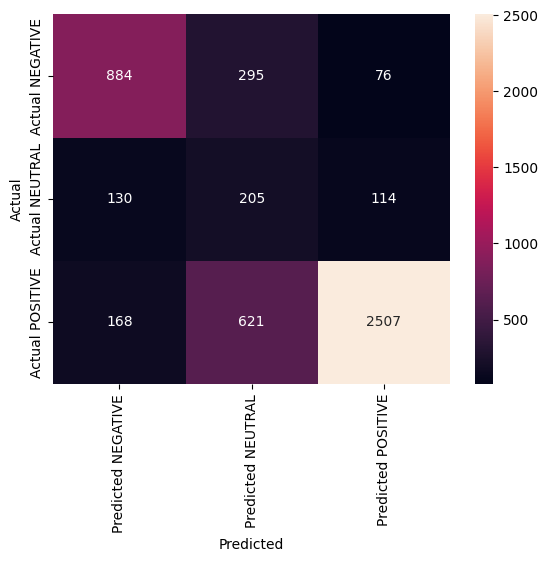

In [19]:
conf_mat = confusion_matrix(

    y_true=test_labels,

    y_pred=y_pred

)

ticklabels = [

    SENTIMENT_LABEL_MAP[i]

    for i in sorted(SENTIMENT_LABEL_MAP.keys())

]

conf_mat_df = pd.DataFrame(
    conf_mat,
    index=[f"Actual {label}" for label in ticklabels],
    columns=[f"Predicted {label}" for label in ticklabels]
)

print(conf_mat_df)

sns.heatmap(

    conf_mat_df,

    annot=True,

    fmt="d"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Balanced sampling improved BioBERT's ability to detect NEUTRAL reviews compared with the earlier imbalanced training run. However, the overall accuracy and macro F1 remain lower than the TF-IDF + LinearSVC model. The confusion matrix shows that BioBERT over-predicts NEUTRAL for some POSITIVE reviews, which reduces overall accuracy. Based on this result, LinearSVC remains the stronger candidate for deployment in the UI. 

## Predict Some Samples

In [20]:
def predict_biobert_sentiment(text):

    text = normalize_text(text)

    inputs = tokenizer(

        text,

        return_tensors="pt",

        truncation=True,

        padding=True,

        max_length=256

    )

    inputs = {

        key: value.to(model.device)

        for key, value in inputs.items()

    }

    model.eval()

    with torch.no_grad():

        outputs = model(**inputs)

    pred = torch.argmax(

        outputs.logits,

        dim=1

    ).item()

    return SENTIMENT_LABEL_MAP[pred]

In [21]:
predict_biobert_sentiment(
    "This medicine helped cure my throat problem."
)

'POSITIVE'

In [22]:
predict_biobert_sentiment(
    "This medicine did not help curing my throat problem."
)

'NEGATIVE'